## Strategic Analysis & Visualization
**Objective:** Generate actionable football intelligence using the cleaned dataset. We focus on four key strategic pillars:
1.  **Talent Demographics:** Where does the best talent come from?
2.  **Market Efficiency:** Identifying "Hidden Gems" (High Potential / Low Cost).
3.  **Squad Architecture:** Analyzing team depth and positional coverage.
4.  **Contract Management:** Bosman rulings and financial risk assessment.

### 📊 Visualization Setup
* **Libraries:** `Seaborn` (Static statistical plots) and `Plotly` (Interactive dashboards).
* **Configuration:** Applied a custom "Professional" style sheet (DPI 140) for report-quality graphics.

In [1]:
# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Set Professional Style
plt.rcParams['figure.dpi'] = 140
plt.style.use("seaborn-v0_8-whitegrid")

# Load the "Golden Record" created in Notebook 1
df = pd.read_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/RawData/fifa19_eda_ready.csv')

print(f"✅ Data Loaded Successfully! Shape: {df.shape}")
print("Ready for Strategic Analysis...")

✅ Data Loaded Successfully! Shape: (18147, 86)
Ready for Strategic Analysis...


In [2]:
# --- 1. Quality Assessment ---
def quality_report(data):
    print(f"Dataset Shape: {data.shape}")
    print(f"\nMissing Values:\n{data.isnull().sum()[data.isnull().sum() > 0]}")
    print(f"\nDuplicate Rows: {data.duplicated().sum()}")
    

quality_report(df)

Dataset Shape: (18147, 86)

Missing Values:
Series([], dtype: int64)

Duplicate Rows: 0


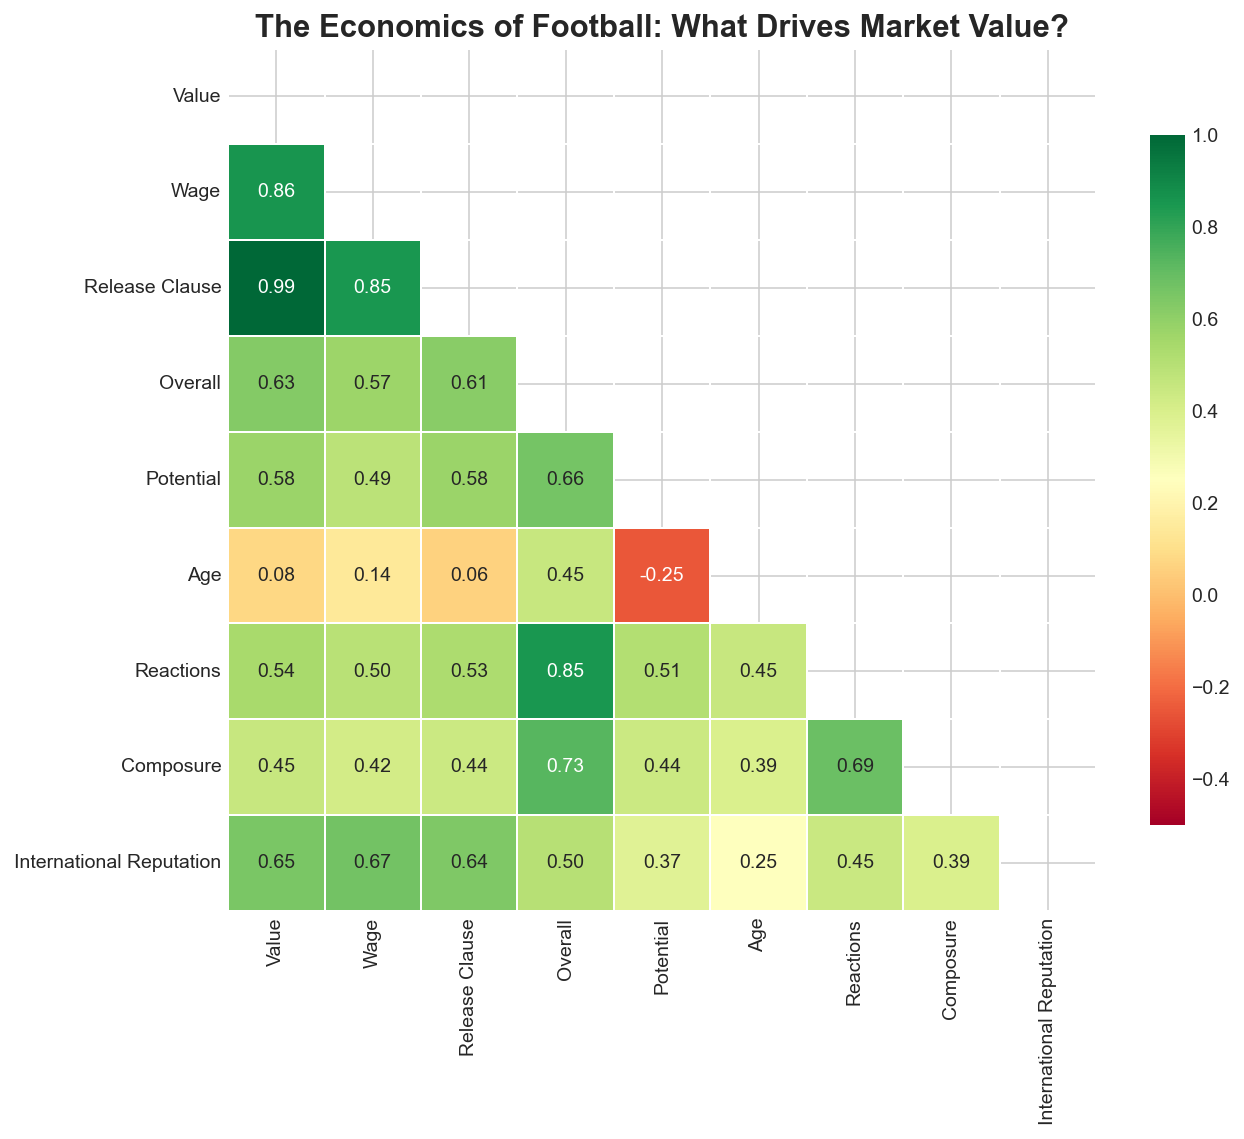

💡 Insight: 'Overall' (0.63) is the primary driver of price, but 'Potential' (0.58) is a massive multiplier.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Select Key Economic & Performance Metrics
val_metrics = [
    'Value', 'Wage', 'Release Clause', 
    'Overall', 'Potential', 'Age', 
    'Reactions', 'Composure', 'International Reputation'
]

# 2. Calculate Correlation Matrix
corr_matrix = df[val_metrics].corr()
corr_matrix_export = corr_matrix.reset_index().rename(columns={'index': 'Metric'})
corr_melted = corr_matrix_export.melt(id_vars='Metric', var_name='Comparison_Metric', value_name='Correlation')
corr_melted.to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/FIFA_Correlation_Matrix.csv', index=False)

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Hide upper triangle redundancy

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="RdYlGn", 
    vmin=-0.5, 
    vmax=1, 
    linewidths=1,
    cbar_kws={"shrink": .8}
)

plt.title("The Economics of Football: What Drives Market Value?", fontsize=16, fontweight='bold')
plt.show()

# Insight Calculation
pot_impact = corr_matrix.loc['Value', 'Potential']
ovr_impact = corr_matrix.loc['Value', 'Overall']
print(f"💡 Insight: 'Overall' ({ovr_impact:.2f}) is the primary driver of price, but 'Potential' ({pot_impact:.2f}) is a massive multiplier.")

In [4]:
import plotly.express as px
import pandas as pd

# ==========================================
# 1. PREPARE DATA
# ==========================================
# We select only the columns needed for this specific visualization
# This keeps the Tableau file lightweight and fast.
export_cols = [
    'Name', 'Club', 'Position', 
    'Overall', 'Value', 'Wage', 
    'Age', 'Release Clause'
]

# Filter out players with 0 Value (usually data errors or retired) to keep the chart clean
market_value_df = df[df['Value'] > 0][export_cols].copy()

# ==========================================
# 2. EXPORT FOR TABLEAU
# ==========================================
market_value_df.to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Market_Value.csv', index=False)
print("✅ File Exported: 'Tableau_Market_Value.csv'")
print(f"   (Contains {len(market_value_df)} players for the Scatter Plot)")

# ==========================================
# 3. VISUALIZE IN NOTEBOOK (Preview)
# ==========================================
fig = px.scatter(
    market_value_df, 
    x="Overall", 
    y="Value", 
    color="Age", 
    size="Wage",
    hover_name="Name", 
    hover_data=["Club", "Position", "Release Clause"],
    title="<b>The Cost of Excellence: Value vs. Overall Rating</b><br><i>(Size = Wage | Color = Age)</i>",
    color_continuous_scale="Turbo",
    template="plotly_white"
)

fig.update_layout(height=600, xaxis_title="Overall Rating", yaxis_title="Market Value (€)")
fig.show()

✅ File Exported: 'Tableau_Market_Value.csv'
   (Contains 17907 players for the Scatter Plot)


In [5]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. PREPARE THE DATA (The Math)
# ==========================================

# A. Filter for "First Team Quality" players only
# (We don't want youth players distorting the wage curve)
mask = (df['Overall'] > 75) & (df['Value'] > 2_000_000) & (df['Wage'] > 2_000)
data = df[mask].copy()

# B. Run the Linear Regression (Log-Log Scale)
# We use Log scale because wages grow exponentially with value
X = np.log(data['Value'].values).reshape(-1, 1)
y = np.log(data['Wage'].values)

model = LinearRegression()
model.fit(X, y)

# C. Calculate "Fair Wage" & "Efficiency Score"
data['Fair_Wage'] = np.exp(model.predict(X))
data['Wage_Delta_Pct'] = ((data['Wage'] - data['Fair_Wage']) / data['Fair_Wage']) * 100

# D. Create the STATUS TAGS (Crucial for Tableau Coloring)
def get_status(pct):
    if pct < -30: 
        return "Target (Underpaid)"  # Green
    elif pct > 30: 
        return "Avoid (Overpaid)"    # Red
    else: 
        return "Normal Market"       # Grey

data['Wage_Status'] = data['Wage_Delta_Pct'].apply(get_status)

# ==========================================
# 2. EXPORT TO CSV (For Tableau)
# ==========================================

# Select only the columns needed for this specific chart
tableau_cols = [
    'Name', 'Club', 'Overall', 'Position',
    'Value', 'Wage', 
    'Fair_Wage', 'Wage_Delta_Pct', 'Wage_Status'
]

# Save the file
data[tableau_cols].to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Wage_Efficiency.csv', index=False)
print("✅ File Saved: 'Tableau_Wage_Efficiency.csv'")

# ==========================================
# 3. VERIFY WITH PLOTLY (Optional: Just to check)
# ==========================================

# Split data for coloring
normal = data[data['Wage_Status'] == 'Normal Market']
bargains = data[data['Wage_Status'] == 'Target (Underpaid)']
overpaid = data[data['Wage_Status'] == 'Avoid (Overpaid)']

fig = go.Figure()

# A. Normal (Grey)
fig.add_trace(go.Scatter(
    x=normal['Value'], y=normal['Wage'], mode='markers', name='Normal',
    marker=dict(color='#999999', size=6, opacity=0.4),
    text=normal['Name'],
    customdata=np.stack((normal['Club'], normal['Overall'], normal['Value'], normal['Wage'], normal['Wage_Delta_Pct']), axis=-1),
    hovertemplate="<b>%{text}</b><br>" +
                  "Club: %{customdata[0]}<br>" +
                  "Overall: %{customdata[1]}<br>" +
                  "Value: €%{customdata[2]:,.0f}<br>" +
                  "Wage: €%{customdata[3]:,.0f}<br>" +
                  "<b>Status: Fair Price </b><extra></extra>"
))

# B. Overpaid (Red)
fig.add_trace(go.Scatter(
    x=overpaid['Value'], y=overpaid['Wage'], mode='markers', name='Overpaid',
    marker=dict(color='#D9534F', size=8, line=dict(width=1, color='DarkRed')),
    text=overpaid['Name'],
    customdata=np.stack((overpaid['Club'], overpaid['Overall'], overpaid['Value'], overpaid['Wage'], overpaid['Wage_Delta_Pct']), axis=-1),
    hovertemplate="<b>%{text}</b><br>" +
                  "Club: %{customdata[0]}<br>" +
                  "Overall: %{customdata[1]}<br>" +
                  "Value: €%{customdata[2]:,.0f}<br>" +
                  "Wage: €%{customdata[3]:,.0f}<br>" +
                  "<b>Status: Overpaid by +%{customdata[4]:.1f}%</b><extra></extra>"
))

# C. Bargains (Green)
fig.add_trace(go.Scatter(
    x=bargains['Value'], y=bargains['Wage'], mode='markers', name='Bargain',
    marker=dict(color='#2CA02C', size=10, line=dict(width=1, color='DarkGreen')),
    text=bargains['Name'],
    customdata=np.stack((bargains['Club'], bargains['Overall'], bargains['Value'], bargains['Wage'], bargains['Wage_Delta_Pct']), axis=-1),
    hovertemplate="<b>%{text}</b><br>" +
                  "Club: %{customdata[0]}<br>" +
                  "Overall: %{customdata[1]}<br>" +
                  "Value: €%{customdata[2]:,.0f}<br>" +
                  "Wage: €%{customdata[3]:,.0f}<br>" +
                  "<b>Status: Underpaid by %{customdata[4]:.1f}%</b><extra></extra>"
))

# D. Trendline
x_range = np.linspace(data['Value'].min(), data['Value'].max(), 100)
y_pred = np.exp(model.predict(np.log(x_range).reshape(-1, 1)))
fig.add_trace(go.Scatter(x=x_range, y=y_pred, mode='lines', line=dict(color='black', dash='dash'), name='Fair Value Line'))

fig.update_layout(
    title="<b>Wage Efficiency Radar</b>",
    xaxis_type="log", yaxis_type="log",
    xaxis_title="Value (€)", yaxis_title="Wage (€)",
    template="plotly_white", height=600
)
fig.show()

✅ File Saved: 'Tableau_Wage_Efficiency.csv'


C:\Users\terbo\AppData\Local\Temp\ipykernel_20116\3255496043.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




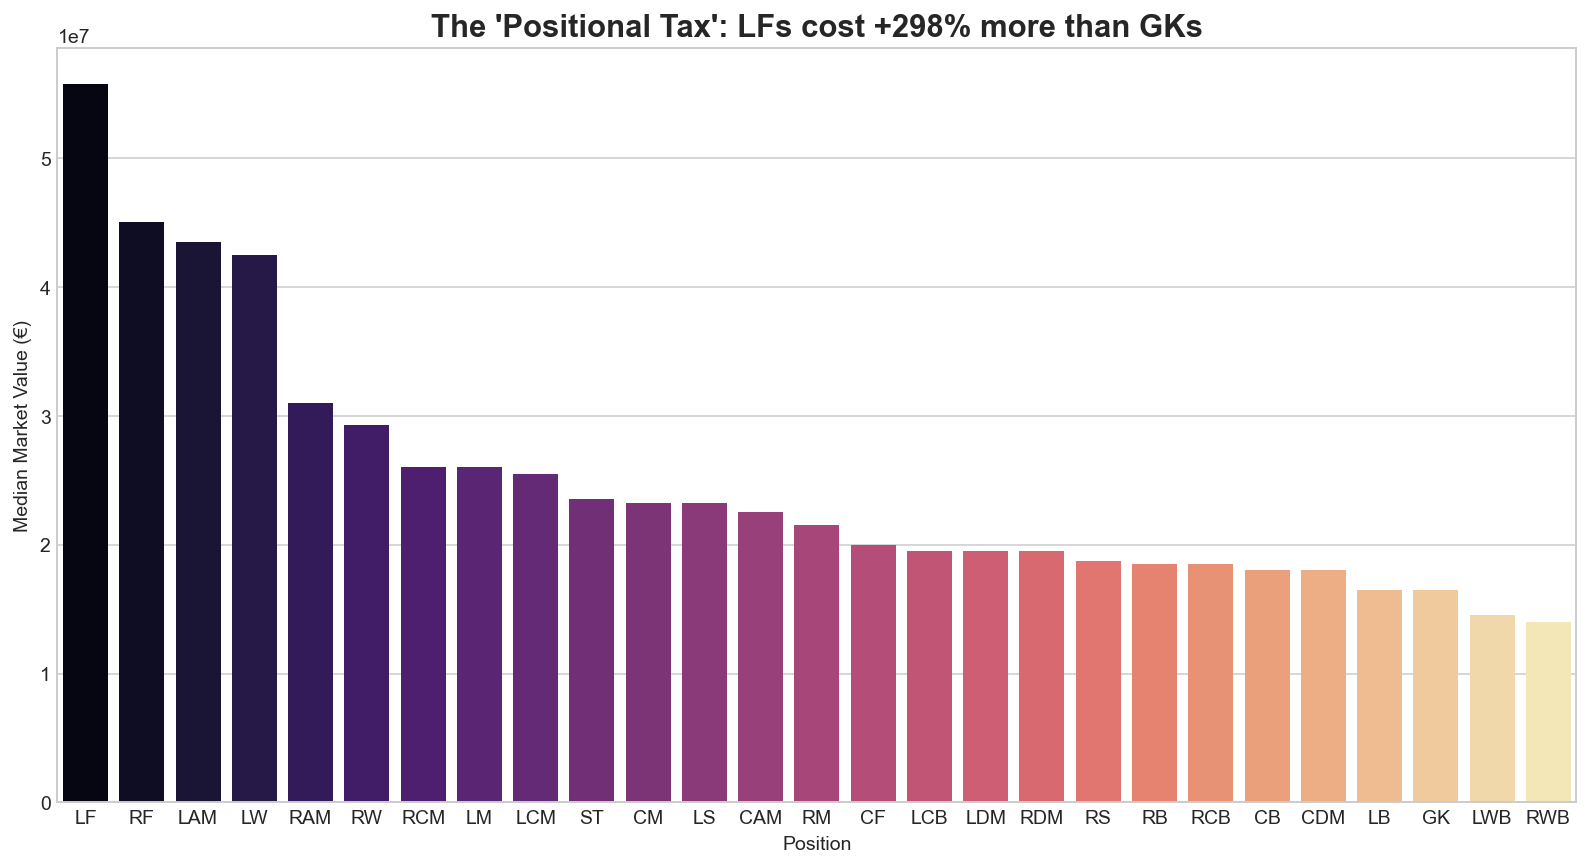

✅ File Exported: 'Tableau_Positional_Tax.csv'
👉 In Tableau: Drag 'Position' to Columns, 'Median_Value' to Rows, and 'Premium_Pct' to Label.


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. CALCULATE THE "POSITIONAL TAX"
# ==========================================

# A. Filter for "Elite" Talent only (Overall >= 80)
# We only want to analyze the price of top-tier players
elite_players = df[df['Overall'] >= 80].copy()

# B. Calculate Median Cost per Position
# We use Median because 'Value' has huge outliers (like Neymar/Messi)
pos_tax = elite_players.groupby('Position')[['Value']].median().reset_index()
pos_tax.columns = ['Position', 'Median_Value']

# C. Calculate the "Premium" (The Insight)
# How much more expensive is this position compared to the cheapest position (usually GK)?
cheapest_price = pos_tax['Median_Value'].min()
pos_tax['Premium_Pct'] = ((pos_tax['Median_Value'] - cheapest_price) / cheapest_price) * 100

# Sort for the chart
pos_tax = pos_tax.sort_values('Median_Value', ascending=False)

# ==========================================
# 2. VISUALIZE IN PYTHON (Sanity Check)
# ==========================================
plt.figure(figsize=(14, 7))
sns.barplot(data=pos_tax, x='Position', y='Median_Value', palette='magma')

# Add the text label dynamically
expensive_pos = pos_tax.iloc[0]['Position']
premium = pos_tax.iloc[0]['Premium_Pct']
plt.title(f"The 'Positional Tax': {expensive_pos}s cost +{premium:.0f}% more than GKs", fontsize=16, fontweight='bold')
plt.ylabel("Median Market Value (€)")
plt.show()

# ==========================================
# 3. EXPORT FOR TABLEAU
# ==========================================
# This small file makes the Tableau chart instant to build
pos_tax.to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Positional_Tax.csv', index=False)

print("✅ File Exported: 'Tableau_Positional_Tax.csv'")
print("👉 In Tableau: Drag 'Position' to Columns, 'Median_Value' to Rows, and 'Premium_Pct' to Label.")

In [7]:
import plotly.express as px
import pandas as pd

# ==========================================
# 1. PREPARE DATA & SMART LABELS
# ==========================================

# A. Group by Region (Ensure 'Nationality_Region' exists in df)
# If you don't have 'Nationality_Region', change to 'Nationality'
group_col = 'Nationality_Region' if 'Nationality_Region' in df.columns else 'Nationality'

region_stats = df.groupby(group_col).agg({
    'Value': 'median',       # Y-Axis: Typical Price
    'Overall': 'mean',       # X-Axis: Average Quality
    'Name': 'count'          # Size: Pool Depth
}).rename(columns={'Name': 'Player_Count'}).reset_index()

# B. Calculate Global Averages (For Quadrant Lines)
avg_quality = region_stats['Overall'].mean()
avg_price = region_stats['Value'].mean()

# C. Create "Smart Labels" (Clean up the noise)
# Logic: We only show text if the region is BIG, or VERY GOOD, or VERY EXPENSIVE.
threshold_count = region_stats['Player_Count'].quantile(0.70) # Top 30% biggest regions

def get_smart_label(row):
    is_big = row['Player_Count'] > threshold_count
    is_elite = row['Overall'] > avg_quality + 2  # Better than avg
    is_expensive = row['Value'] > avg_price * 1.5 # Expensive outlier
    
    if is_big or is_elite or is_expensive:
        return row[group_col]
    return "" # Empty string hides the label

region_stats['Label'] = region_stats.apply(get_smart_label, axis=1)

# ==========================================
# 2. EXPORT FOR TABLEAU (The New Part)
# ==========================================
# This saves the pre-calculated matrix.
# In Tableau: Drag 'Overall' to Columns, 'Value' to Rows, 'Label' to Label.
region_stats.to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Scouting_Regions.csv', index=False)

print("✅ File Exported: 'Tableau_Scouting_Regions.csv'")
print(f"   (Use Reference Lines in Tableau: Avg Quality = {avg_quality:.1f}, Avg Price = €{avg_price:,.0f})")

# ==========================================
# 3. VISUALIZE IN PYTHON (Preview)
# ==========================================
fig = px.scatter(
    region_stats,
    x="Overall",
    y="Value",
    size="Player_Count",
    color=group_col,
    text="Label",  # <--- Uses the filtered labels we just made
    
    title="<b>Strategic Scouting Matrix</b><br><i>(Showing Major Markets | Bubble Size = Player Count)</i>",
    labels={
        "Player_Count": "Player Count", 
        "Overall": "Avg Region Quality", 
        "Value": "Median Price (€)"
    },
    hover_name=group_col,
    hover_data={'Label': False},
    template="plotly_white",
    size_max=60
)

# Add Context: Quadrant Backgrounds
# Green Zone (High Quality, Low Price)
fig.add_shape(type="rect",
    x0=avg_quality, y0=0, x1=region_stats['Overall'].max()*1.05, y1=avg_price,
    line=dict(width=0), fillcolor="green", opacity=0.05, layer="below")

# Premium Zone (High Quality, High Price)
fig.add_shape(type="rect",
    x0=avg_quality, y0=avg_price, x1=region_stats['Overall'].max()*1.05, y1=region_stats['Value'].max()*1.1,
    line=dict(width=0), fillcolor="orange", opacity=0.05, layer="below")

# Add Reference Lines (Averages)
fig.add_hline(y=avg_price, line_dash="dot", line_color="grey", annotation_text="Avg Price")
fig.add_vline(x=avg_quality, line_dash="dot", line_color="grey", annotation_text="Avg Quality", annotation_position="top left")

fig.update_traces(textposition='top center', textfont=dict(size=10, color='black'))
fig.update_layout(showlegend=False, height=700)

fig.show()





✅ File Exported: 'Tableau_Scouting_Regions.csv'
   (Use Reference Lines in Tableau: Avg Quality = 65.5, Avg Price = €650,000)


✅ File Exported: 'Tableau_Age_Curve.csv'
   - Mean Age: 25.1 years
   - Buy Zone: 16-23 years
   - Sell Zone: 26-30 years


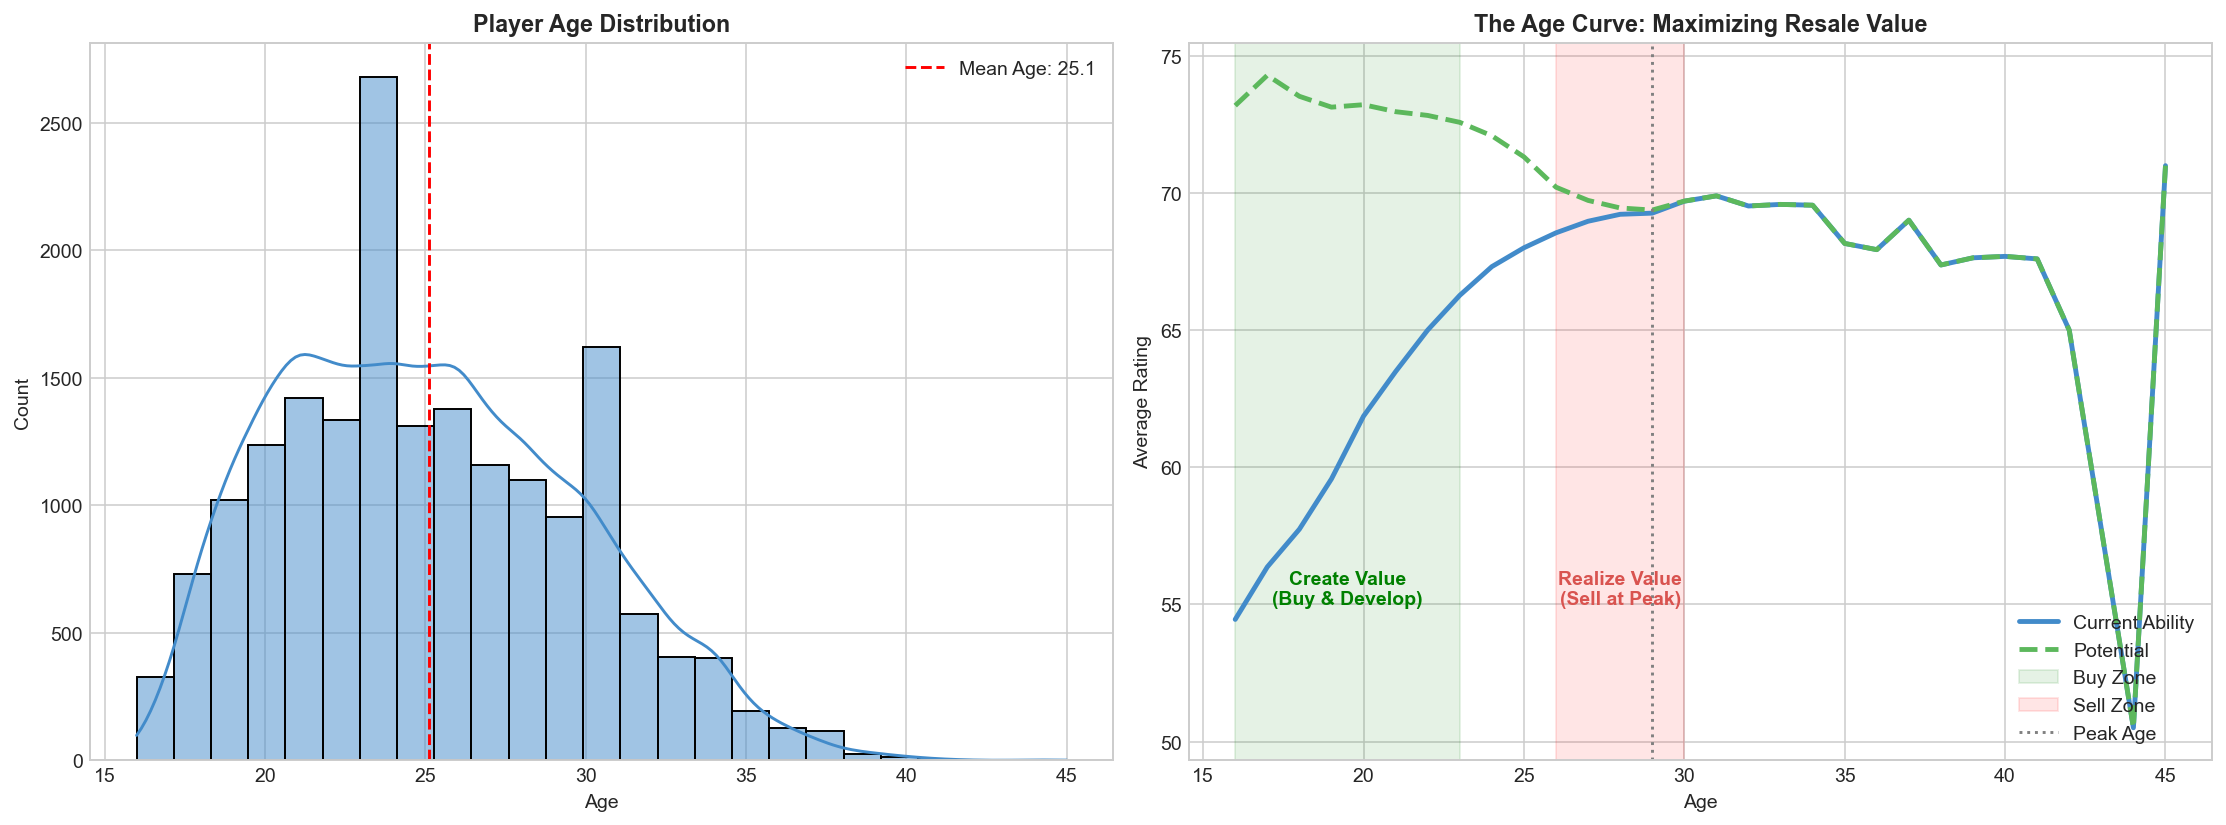

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. PREPARE THE DATA (Aggregations)
# ==========================================

# A. Calculate the "Age Curve" (Mean Rating per Age)
# This creates the smooth lines for Current vs. Potential
age_curve = df.groupby('Age')[['Overall', 'Potential']].mean().reset_index()

# B. Calculate Demographics (for Reference)
avg_age = df['Age'].mean()
peak_age = 29 # As defined in your business logic

# ==========================================
# 2. EXPORT FOR TABLEAU
# ==========================================
# We export the aggregated curve data. 
# For the Histogram, you will use your Main Data file (Count of Age).
age_curve.to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Age_Curve.csv', index=False)

print("✅ File Exported: 'Tableau_Age_Curve.csv'")
print(f"   - Mean Age: {avg_age:.1f} years")
print(f"   - Buy Zone: 16-23 years")
print(f"   - Sell Zone: 26-30 years")

# ==========================================
# 3. VISUALIZE IN PYTHON (Preview)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Demographics (Histogram)
sns.histplot(data=df, x="Age", bins=25, kde=True, color="#428BCA", ax=ax[0])
ax[0].set_title("Player Age Distribution", fontweight='bold')
ax[0].axvline(avg_age, color='red', linestyle='--', label=f"Mean Age: {avg_age:.1f}")
ax[0].legend()

# Chart 2: The Age Curve (Line Plot)
# Note: We use the aggregated 'age_curve' dataframe here to mimic Tableau's behavior
sns.lineplot(data=age_curve, x="Age", y="Overall", label="Current Ability", color="#428BCA", linewidth=2.5, ax=ax[1])
sns.lineplot(data=age_curve, x="Age", y="Potential", label="Potential", color="#5CB85C", linestyle="--", linewidth=2.5, ax=ax[1])

# Highlight Zones (Reference Bands)
ax[1].axvspan(16, 23, color='green', alpha=0.1, label='Buy Zone')
ax[1].axvspan(26, 30, color='red', alpha=0.1, label='Sell Zone')

# Annotations
ax[1].text(19.5, 55, "Create Value\n(Buy & Develop)", color='green', fontweight='bold', ha='center')
ax[1].text(28, 55, "Realize Value\n(Sell at Peak)", color='#D9534F', fontweight='bold', ha='center')

ax[1].set_title("The Age Curve: Maximizing Resale Value", fontweight='bold')
ax[1].set_ylabel("Average Rating")
ax[1].axvline(peak_age, color='grey', linestyle=':', label="Peak Age")
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import plotly.express as px

# ==========================================
# 1. PREPARE DATA (The Math)
# ==========================================

# A. Calculate "Growth" (Potential - Current)
# This is the key metric for "Hidden Gems"
df['Growth'] = df['Potential'] - df['Overall']

# B. Filter for Young Talent (Under 23)
# We only want to invest in players with time to improve
young_talent = df[df['Age'] < 23].copy()

# ==========================================
# 2. EXPORT FOR TABLEAU (The File)
# ==========================================

# Select only what Tableau needs to build this specific chart
tableau_cols = [
    'Name', 
    'Club', 
    'Position',
    'Nationality_Region', # 
    'Age', 
    'Overall',     # X-Axis
    'Potential',   # Y-Axis
    'Value',       # Color
    'Growth'       # Size
]

# Save the file
young_talent[tableau_cols].to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Gem_Finder.csv', index=False)
print("✅ File Exported: 'Tableau_Gem_Finder.csv'")
print(f"   (Contains {len(young_talent)} young players. Open in Tableau to visualize.)")

# ==========================================
# 3. VISUALIZE IN NOTEBOOK (The Preview)
# ==========================================

fig = px.scatter(
    young_talent,
    x="Overall",
    y="Potential",
    color="Value",        # Uses raw numbers (e.g. 1500000)
    size="Growth",
    
    title="<b>The Gem Finder: Current Ability vs. Future Potential</b><br><i>(Bubble Size = Growth Potential)</i>",
    
    # --- 🎯 THE FORMATTING FIXES ---
    # This formats the numbers inside the Python Chart
    hover_name="Name",
    hover_data={
        "Club": True,
        "Age": True,
        "Position": True,
        "Value": ":.2s",  # Formats 1.5M in tooltip
        "Growth": True,
        "Overall": True,
        "Potential": True
    },
    
    labels={
        "Growth": "Growth (+ Ratings)",
        "Value": "Market Value (€)", 
        "Overall": "Current Rating",
        "Potential": "Future Potential"
    },
    
    color_continuous_scale="Turbo",
    template="plotly_white",
    opacity=0.7
)

# Format the Color Bar to show 'M' (Millions) automatically
fig.update_layout(
    height=700,
    xaxis_title="Current Overall Rating",
    yaxis_title="Future Potential Rating",
    xaxis=dict(range=[50, 95]),
    yaxis=dict(range=[50, 99]),
    coloraxis_colorbar=dict(
        title="Value (€)",
        tickformat=".2s"  # Formats legend ticks (e.g. 10M)
    )
)

# Add Context Lines
fig.add_shape(
    type="line", line=dict(dash="dash", color="grey"),
    x0=50, y0=50, x1=95, y1=95
)

fig.add_annotation(
    x=85, y=94, text="<b>Elite Superstars</b><br>(Expensive)", 
    showarrow=False, font=dict(color="red")
)

fig.add_annotation(
    x=65, y=88, text="<b>💎 HIDDEN GEMS</b><br>(High Growth, Low Rating)", 
    showarrow=True, arrowhead=1
)

fig.show()

✅ File Exported: 'Tableau_Gem_Finder.csv'
   (Contains 6073 young players. Open in Tableau to visualize.)


✅ File Exported: 'Tableau_Growth_Dumbbells.csv'


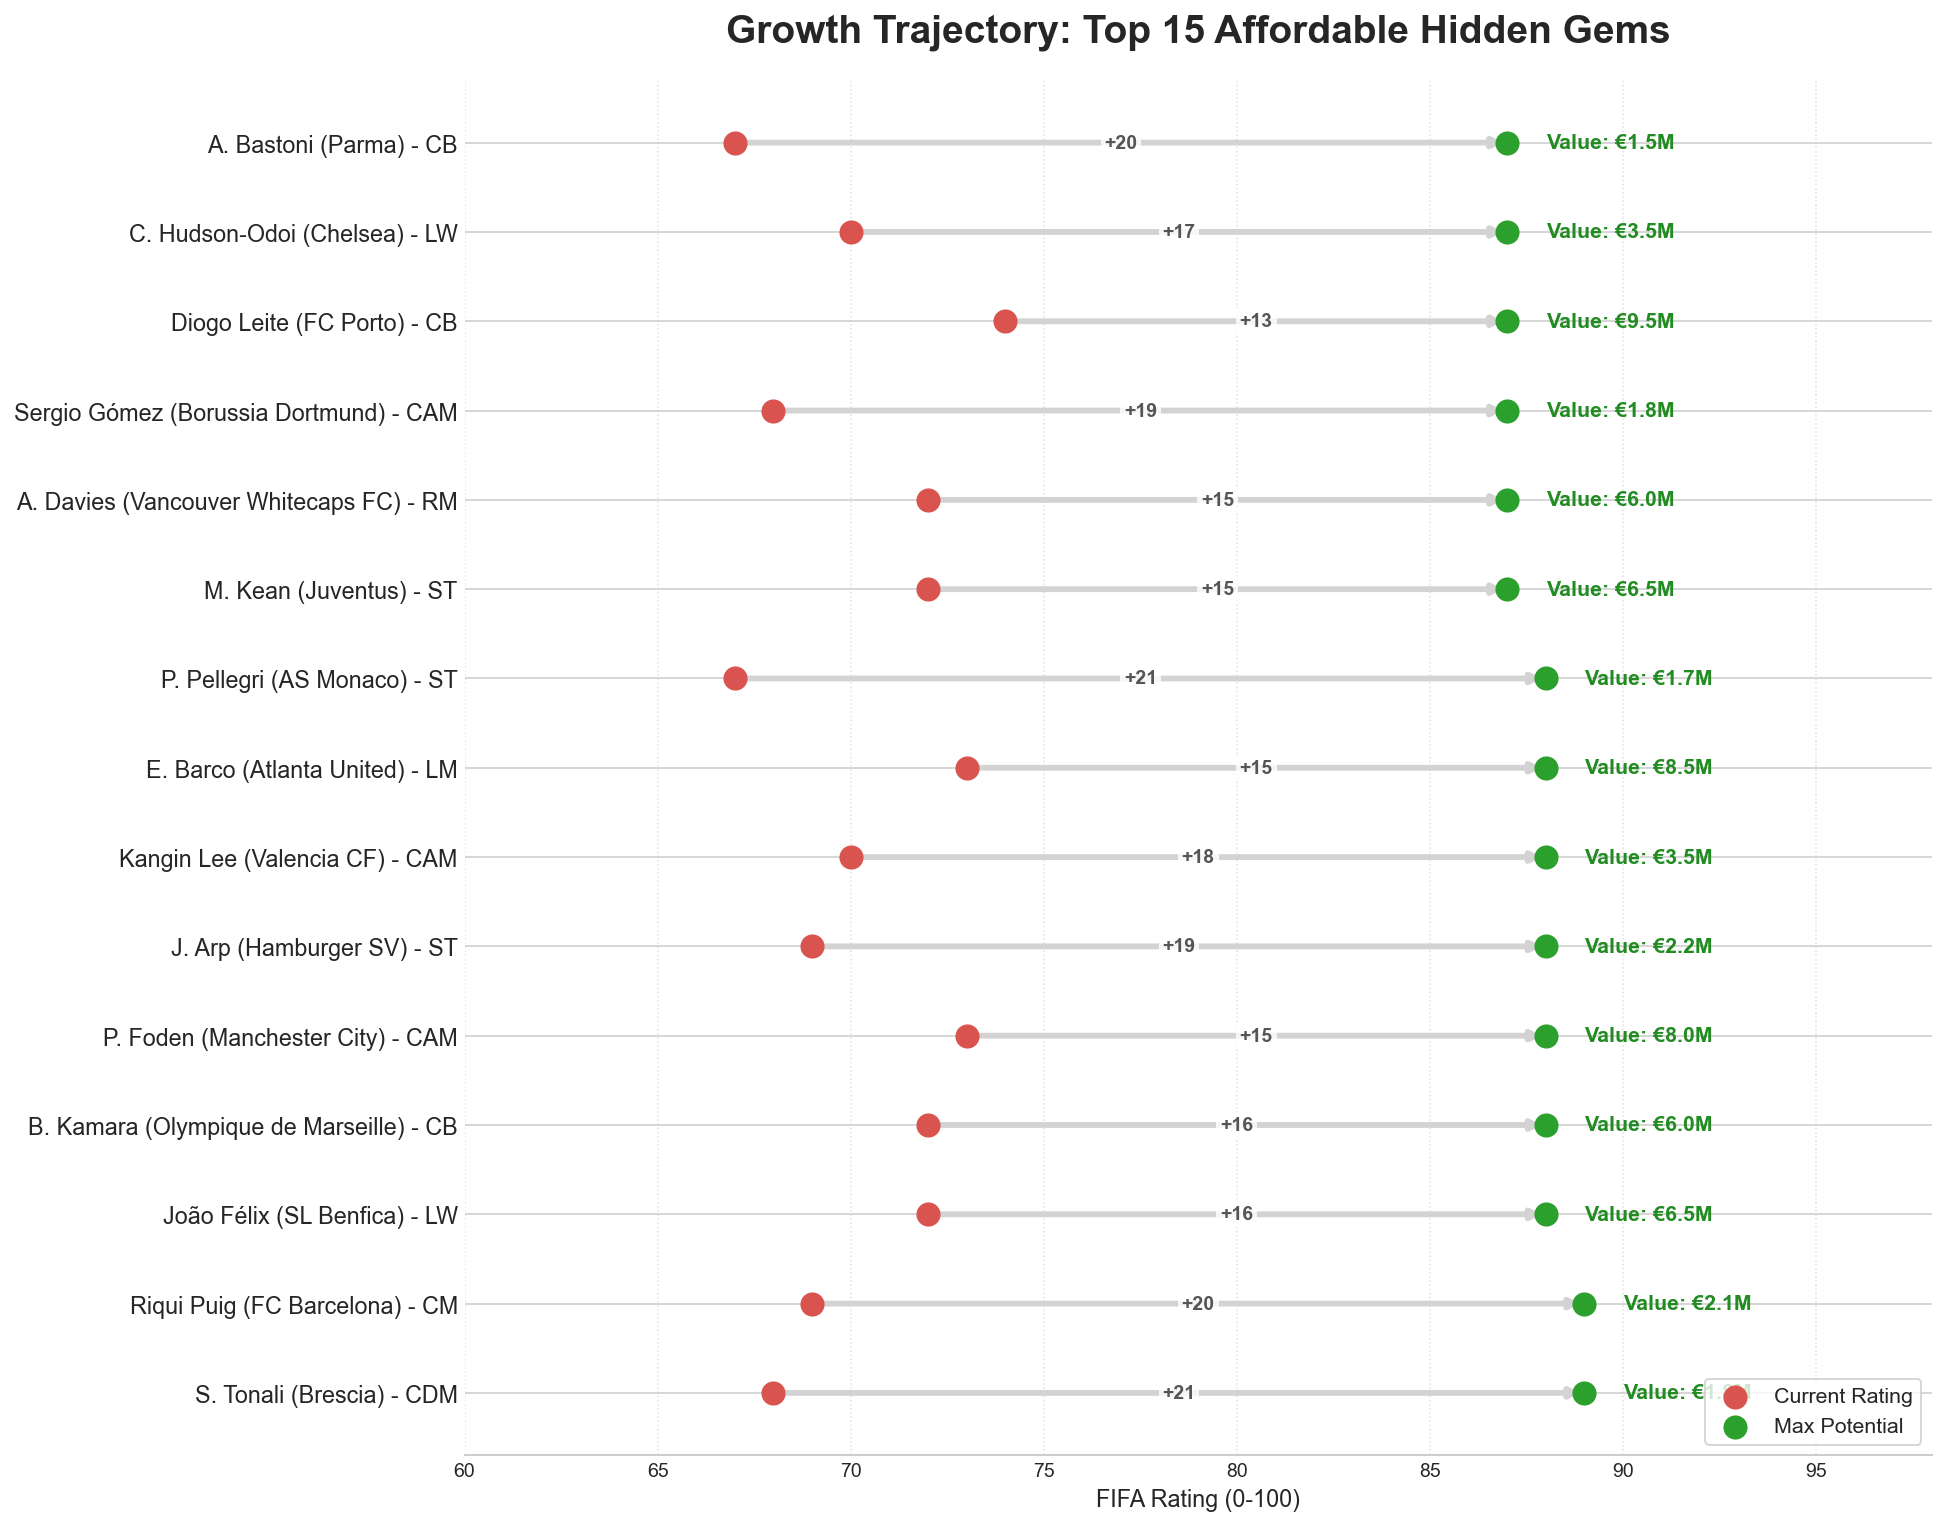

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# 1. PREPARE DATA: The "Elite Cheap"
# ==========================================

# A. Filter: Young (<=21), Cheap (<10M), High Potential (>83)
top_gems = df[
    (df['Age'] <= 21) & 
    (df['Value'] <= 10_000_000) & 
    (df['Potential'] >= 83)
].sort_values(by='Potential', ascending=False).head(15).copy()

# B. Create the "Rich Label" for the Y-Axis (Crucial for Tableau)
# This creates the string: "Mbappé (PSG | ST)"
# 1. Create the Growth Gap (The length of the dumbbell)
top_gems['Growth_Gap'] = top_gems['Potential'] - top_gems['Overall']

# 2. Create the Player Label (Name + Club + Position)
top_gems['Player_Label'] = top_gems['Name'] + " (" + top_gems['Club'] + ") - " + top_gems['Position']

# 3. Create the Value Label (This is the one causing the error)
def format_value(val):
    if val >= 1_000_000:
        return f"€{val/1_000_000:.1f}M"
    elif val >= 1_000:
        return f"€{val/1_000:.0f}K"
    return f"€{int(val)}"

top_gems['Value_Label'] = top_gems['Value'].apply(format_value)

# NOW you can run your export code
export_cols = [
    'Player_Label', 'Name', 'Club', 'Position', 'Nationality_Region',
    'Overall', 'Potential', 'Value', 'Wage', 'Growth_Gap', 'Value_Label'
]
top_gems[export_cols].to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Growth_Dumbbells.csv', index=False)
print("✅ File Exported: 'Tableau_Growth_Dumbbells.csv'")

# ==========================================
# 3. VISUALIZE IN PYTHON (The Enhanced Preview)
# ==========================================
plt.figure(figsize=(14, 11)) 

for i in range(len(top_gems)):
    row = top_gems.iloc[i]
    
    # A. The Path (With Arrow)
    plt.annotate(
        "", 
        xy=(row['Potential'], i), xycoords='data',
        xytext=(row['Overall'], i), textcoords='data',
        arrowprops=dict(arrowstyle="-|>", color='lightgrey', lw=3)
    )
    
    # B. The Start Point (Red = Current)
    plt.scatter(row['Overall'], i, color='#D9534F', s=130, zorder=3, label='Current Rating' if i == 0 else "")
    
    # C. The End Point (Green = Potential)
    plt.scatter(row['Potential'], i, color='#2CA02C', s=130, zorder=3, label='Max Potential' if i == 0 else "")
    
    # D. The Value Label (With "Val:" prefix)
    plt.text(
        row['Potential'] + 1.0, i, 
        f"Value: €{row['Value']/1e6:.1f}M", 
        va='center', color='#228B22', fontsize=11, fontweight='bold'
    )
    
    # E. The Growth Label (With White Box)
    midpoint = (row['Overall'] + row['Potential']) / 2
    plt.text(
        midpoint, i, 
        f"+{row['Growth_Gap']}", 
        ha='center', va='center', fontsize=10, color='#555555', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2)
    )

# Formatting
plt.yticks(range(len(top_gems)), top_gems['Player_Label'], fontsize=12)
plt.title("Growth Trajectory: Top 15 Affordable Hidden Gems", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("FIFA Rating (0-100)", fontsize=12)
plt.xlim(60, 98) 
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True, fontsize=11)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ==========================================
# 1. PREPARE DATA & CALCULATE THE STORY
# ==========================================

# A. Calculate Metrics (Same as before)
skill_cols = [
    'Crossing','Finishing','HeadingAccuracy','ShortPassing','Volleys',
    'Dribbling','Curve','FKAccuracy','LongPassing','BallControl',
    'Acceleration','SprintSpeed','Agility','Reactions','Balance',
    'ShotPower','Jumping','Stamina','Strength','LongShots',
    'Aggression','Interceptions','Positioning','Vision','Penalties',
    'Composure','Marking','StandingTackle','SlidingTackle'
]
df['Total_Skills'] = df[skill_cols].sum(axis=1)

# B. Filter Candidates
targets = df[
    (df['Total_Skills'] > 2050) & 
    (df['Value'] < 20_000_000) & 
    (df['Value'] > 4_000_000) &
    (df['Position'] != 'GK')
].copy()

targets['ROI_Score'] = targets['Total_Skills'] / (targets['Value'] / 1_000_000)
top_bargains = targets.sort_values(by='ROI_Score', ascending=False).head(10).copy()

# C. Add The "Villain" (Benchmark) for Contrast
benchmark = df[df['Name'] == 'P. Pogba'].copy()
if not benchmark.empty:
    benchmark['ROI_Score'] = benchmark['Total_Skills'] / (benchmark['Value'] / 1_000_000)
    # Mark types for coloring
    benchmark['Player_Type'] = "Expensive Benchmark" 
    top_bargains['Player_Type'] = "Smart Bargain"
    
    # Calculate the "Multiplier Insight"
    # How much better is the #1 Bargain compared to Pogba?
    best_deal_score = top_bargains.iloc[0]['ROI_Score']
    pogba_score = benchmark.iloc[0]['ROI_Score']
    multiplier = best_deal_score / pogba_score
    
    final_df = pd.concat([top_bargains, benchmark])
else:
    top_bargains['Player_Type'] = "Smart Bargain"
    final_df = top_bargains
    multiplier = 1

# ==========================================
# 2. EXPORT FOR TABLEAU
# ==========================================
final_df.to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_ROI_Story.csv', index=False)
print("✅ File Exported: 'Tableau_ROI_Story.csv'")

# ==========================================
# 3. VISUALIZE: THE "STORYTELLING" PLOT
# ==========================================

# We use colors to separate the "Good" from the "Bad"
fig = px.bar(
    final_df,
    x="ROI_Score",
    y="Name",
    orientation='h',
    color="Player_Type",  # <--- This splits the colors automatically
    color_discrete_map={
        "Smart Bargain": "#2CA02C",       # Green
        "Expensive Benchmark": "#D9534F"  # Red
    },
    text="Value",
    title="<b>The Efficiency Gap: Bargains vs. Superstars</b>",
    template="plotly_white"
)

# A. Add the Benchmark Line
fig.add_vline(x=pogba_score, line_width=2, line_dash="dash", line_color="red")

# B. Add the "Story" Annotation (The Arrow)
# Points from the Benchmark to the Top Player
top_player_name = top_bargains.iloc[0]['Name']

fig.add_annotation(
    x=pogba_score + (best_deal_score - pogba_score)/2, # Position in the middle
    y=5, # Approximate middle of the bars
    text=f"<b>PROFIT OPPORTUNITY:<br>Top players here are {multiplier:.1f}x<br>more efficient than Pogba!</b>",
    showarrow=False,
    font=dict(size=14, color="darkgreen"),
    bgcolor="rgba(255,255,255,0.9)",
    bordercolor="green"
)

# C. Formatting
fig.update_traces(texttemplate="€%{text:,.2s}", textposition="inside")
fig.update_layout(
    height=600,
    yaxis={'categoryorder':'total ascending'},
    xaxis_title="Skill Points gained per €1 Million Spent",
    yaxis_title="",
    legend_title_text=""
)

fig.show()

✅ File Exported: 'Tableau_ROI_Story.csv'


In [12]:
import pandas as pd
import plotly.graph_objects as go

# ==========================================
# 1. PREPARE DATA: UNIVERSAL DEPTH CALCULATOR
# ==========================================

# A. Define Roles (The 4-Group System)
position_map = {
    'ST': 'Attacker', 'LW': 'Attacker', 'RW': 'Attacker', 'CF': 'Attacker', 'LS': 'Attacker', 'RS': 'Attacker', 'LF': 'Attacker', 'RF': 'Attacker',
    'CAM': 'Midfielder', 'CM': 'Midfielder', 'CDM': 'Midfielder', 'LM': 'Midfielder', 'RM': 'Midfielder', 'LAM': 'Midfielder', 'RAM': 'Midfielder', 'LCM': 'Midfielder', 'RCM': 'Midfielder',
    'CB': 'Defender', 'LB': 'Defender', 'RB': 'Defender', 'LWB': 'Defender', 'RWB': 'Defender', 'LCB': 'Defender', 'RCB': 'Defender',
    'GK': 'Goalkeeper'
}
df['General_Pos'] = df['Position'].map(position_map)

# B. Calculate Depth for EVERY Club
depth_rows = []
all_clubs = df['Club'].unique()

for club in all_clubs:
    club_df = df[df['Club'] == club]
    
    for pos in ['Goalkeeper', 'Defender', 'Midfielder', 'Attacker']:
        # Get players in this role, sorted by rating
        players = club_df[club_df['General_Pos'] == pos].sort_values('Overall', ascending=False)
        
        if len(players) >= 2:
            starter = players.iloc[0]
            backup = players.iloc[1]
            gap = starter['Overall'] - backup['Overall']
            
            depth_rows.append({
                'Club': club,          # <--- Critical for Tableau Filter
                'Position': pos,
                'Starter_Name': starter['Name'],
                'Starter_Rating': starter['Overall'],
                'Backup_Name': backup['Name'],
                'Backup_Rating': backup['Overall'],
                'Gap': gap
            })

depth_df = pd.DataFrame(depth_rows)

# ==========================================
# 2. EXPORT FOR TABLEAU
# ==========================================
depth_df.to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Squad_Depth.csv', index=False)
print(f"✅ File Exported: 'Tableau_Squad_Depth.csv' ({len(depth_df)} rows)")

# ==========================================
# 3. VISUALIZE (Preview for ONE Team)
# ==========================================
# This lets you test the logic inside Python before switching
team_name = 'Juventus' # Change to test others
team_data = depth_df[depth_df['Club'] == team_name]

fig = go.Figure()

for i, row in team_data.iterrows():
    # A. The Line
    fig.add_trace(go.Scatter(
        x=[row['Backup_Rating'], row['Starter_Rating']], y=[row['Position'], row['Position']],
        mode='lines', line=dict(color='lightgrey', width=4), hoverinfo='skip', showlegend=False
    ))
    
    # B. The Gap Label
    midpoint = (row['Starter_Rating'] + row['Backup_Rating']) / 2
    fig.add_annotation(
        x=midpoint, y=row['Position'], text=f"Gap: +{row['Gap']}", 
        showarrow=False, yshift=15, font=dict(size=10, color="grey")
    )

# C. The Dots
fig.add_trace(go.Scatter(
    x=team_data['Backup_Rating'], y=team_data['Position'], mode='markers', name='Backup',
    marker=dict(color='#D9534F', size=14),
    text=team_data['Backup_Name'], hovertemplate="<b>Backup: %{text}</b> (%{x})<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=team_data['Starter_Rating'], y=team_data['Position'], mode='markers', name='Starter',
    marker=dict(color='#2CA02C', size=18),
    text=team_data['Starter_Name'], hovertemplate="<b>Starter: %{text}</b> (%{x})<extra></extra>"
))

fig.update_layout(
    title=f"<b>Squad Depth Risk: {team_name}</b>",
    xaxis_title="Overall Rating", xaxis=dict(range=[60, 95]),
    template="plotly_white", height=500
)
fig.show()

✅ File Exported: 'Tableau_Squad_Depth.csv' (2605 rows)


In [13]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# ==========================================
# 1. SETUP & ENGINE CONFIGURATION
# ==========================================

# A. Define the 29 tactical attributes that define "Style"
feature_cols = [
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
    'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
    'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
    'Composure', 'Marking', 'StandingTackle', 'SlidingTackle'
]

# B. Check for Dataframe (Ensure 'df' is loaded)
if 'df' in locals():
    # Clean data
    knn_df = df.dropna(subset=feature_cols).copy()
    
    # Fit the Model
    model = NearestNeighbors(n_neighbors=200, algorithm='brute', metric='euclidean')
    model.fit(knn_df[feature_cols])
    print("✅ Engine Configured Successfully.")
else:
    print("⚠️ WARNING: Please load your dataset into a variable named 'df' before running this.")


def fetch_smart_backups(target_name):
    # --- A. Validation ---
    if target_name not in knn_df['Name'].values:
        print(f"❌ Error: Player '{target_name}' not found.")
        return

    # --- B. Get Target Profile ---
    target = knn_df[knn_df['Name'] == target_name].iloc[0]
    target_stats = pd.DataFrame([target[feature_cols]], columns=feature_cols)
    target_pos = target['Position'] # <--- Capture target position
    budget_cap = target['Value'] * 0.80 
    
    print(f"🎯 STARTER: {target_name} ({target['Overall']} OVR | {target_pos})")
    print(f"💎 Market Value: €{target['Value']:,.0f}")
    print("-" * 60)

    # --- C. Find Neighbors (Increased to 500 to ensure position matches found) ---
    distances, indices = model.kneighbors(target_stats, n_neighbors=500)
    candidates = knn_df.iloc[indices[0]].copy()
    candidates['Distance'] = distances[0]
    
    # --- D. APPLY FILTERS (Now including Position) ---
    backups = candidates[
        (candidates['Name'] != target_name) &
        (candidates['Position'] == target_pos) & # <--- STRICT POSITION MATCH
        (candidates['Overall'].between(target['Overall'] - 8, target['Overall'] - 1)) & 
        (candidates['Value'] <= budget_cap) & 
        (candidates['Wage'] < target['Wage'])
    ].copy()
    
    if backups.empty:
        print(f"⚠️ No backups found for position {target_pos}. Try using 'General_Pos' for a wider search.")
        return

    # --- E. METRICS & SCORING ---
    backups['Similarity'] = 100 - (backups['Distance'] * 1.5)
    backups['Discount'] = ((target['Value'] - backups['Value']) / target['Value']) * 100
    backups['Rating_Gap'] = backups['Overall'] - target['Overall']
    
    top_options = backups.sort_values('Similarity', ascending=False).head(5)

    # --- F. DISPLAY TABLE ---
    print(f"✅ FOUND {len(top_options)} SMART {target_pos} OPTIONS:")
    
    display_cols = ['Name', 'Age', 'Club', 'Overall', 'Rating_Gap', 'Value', 'Wage', 'Similarity', 'Discount']
    
    styled = top_options[display_cols].style.format({
        "Value": "€{:,.0f}",
        "Wage": "€{:,.0f}",
        "Similarity": "{:.1f}%",
        "Discount": "-{:.0f}%",
        "Rating_Gap": "{:+.0f}"
    }).background_gradient(subset=['Similarity'], cmap='Greens') \
      .bar(subset=['Rating_Gap'], color='#d65f5f', align='mid', vmax=0)
    
    display(styled)

    # --- G. VISUALIZATION (Python Plotly) ---
    best_clone = top_options.iloc[0]
    categories = ['SprintSpeed', 'Finishing', 'ShortPassing', 'Dribbling', 'StandingTackle', 'Strength']
    
    starter_vals = [target[c] for c in categories]
    backup_vals = [best_clone[c] for c in categories]
    gap_vals = [b - s for b, s in zip(backup_vals, starter_vals)]
    
    fig = make_subplots(
        rows=2, cols=1, 
        row_heights=[0.7, 0.3],
        specs=[[{'type': 'polar'}], [{'type': 'xy'}]],
        subplot_titles=(f"Style Match: {target['Name']} vs {best_clone['Name']}", "Attribute Gap Analysis")
    )

    # Radar Traces
    fig.add_trace(go.Scatterpolar(r=starter_vals, theta=categories, fill='toself', name='Starter', line_color='#1F77B4'), row=1, col=1)
    fig.add_trace(go.Scatterpolar(r=backup_vals, theta=categories, fill='toself', name='Backup', line_color='#2CA02C'), row=1, col=1)

    # Gap Bar Trace
    colors = ['#d65f5f' if x < 0 else '#2ca02c' for x in gap_vals]
    fig.add_trace(go.Bar(x=categories, y=gap_vals, marker_color=colors, text=gap_vals, textposition='auto', name='Gap'), row=2, col=1)

    fig.update_layout(height=700, template="plotly_white", title_text="<b>Smart Backup Analysis</b>")
    fig.update_yaxes(range=[-25, 25], row=2, col=1)
    fig.show()
    
    # --- H. EXPORT FOR TABLEAU ---
    # Automatically export the best match data
    # export_for_tableau(target, best_clone, categories)

# ==========================================
# 4. RUN THE ENGINE
# ==========================================
# Just change the name here!
fetch_smart_backups('Cristiano Ronaldo')

✅ Engine Configured Successfully.
🎯 STARTER: Cristiano Ronaldo (94 OVR | ST)
💎 Market Value: €77,000,000
------------------------------------------------------------
✅ FOUND 2 SMART ST OPTIONS:


,Name,Age,Club,Overall,Rating_Gap,Value,Wage,Similarity,Discount
36,G. Bale,28,Real Madrid,88,-6,"€60,000,000","€355,000",3.5%,-22%
48,C. Immobile,28,Lazio,87,-7,"€52,000,000","€115,000",-2.5%,-32%


In [14]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

# ==========================================
# 1. SETUP ENGINE
# ==========================================
feature_cols = [
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
    'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
    'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
    'Composure', 'Marking', 'StandingTackle', 'SlidingTackle'
]

if 'df' in locals():
    knn_df = df.dropna(subset=feature_cols).copy()
    model = NearestNeighbors(n_neighbors=500, algorithm='brute', metric='euclidean')
    model.fit(knn_df[feature_cols])
    print("✅ Engine Configured.")
else:
    print("⚠️ Please load your dataframe into 'df' first.")

# ==========================================
# 2. THE REFRESH FUNCTION
# ==========================================
def refresh_radar_data(min_rating=80):
    print(f"🚀 Refreshing 'radar_data.csv' for players rated > {min_rating} with Positional Matching...")
    
    targets = knn_df[knn_df['Overall'] >= min_rating]['Name'].unique()
    master_list = []
    
    for count, target_name in enumerate(targets):
        if count % 50 == 0: print(f"   ...Processed {count} players")

        try:
            target_row = knn_df[knn_df['Name'] == target_name].iloc[0]
        except IndexError: continue

        target_stats = pd.DataFrame([target_row[feature_cols]], columns=feature_cols)
        target_pos = target_row['Position'] # <--- Target Position
        budget_cap = target_row['Value'] * 0.75 # Increased slightly for better data density
        
        # Find 500 neighbors to ensure we find the same position within the style match
        distances, indices = model.kneighbors(target_stats, n_neighbors=500)
        candidates = knn_df.iloc[indices[0]].copy()
        candidates['Distance'] = distances[0]
        
        # Filter by Name, Position, Rating, and Value
        backups = candidates[
            (candidates['Name'] != target_name) &
            (candidates['Position'] == target_pos) & # <--- POSITION FILTER
            (candidates['Overall'].between(target_row['Overall'] - 8, target_row['Overall'] - 1)) & 
            (candidates['Value'] <= budget_cap)
        ].copy()
        
        if backups.empty: continue
            
        # Get Best Match
        backups['Similarity'] = 100 - (backups['Distance'] * 1.5)
        best_backup = backups.sort_values('Similarity', ascending=False).iloc[0]
        
        # D. Calculate Metadata (For the Tableau Title)
        rating_gap = best_backup['Overall'] - target_row['Overall']
        discount = ((target_row['Value'] - best_backup['Value']) / target_row['Value']) * 100
        
        # E. Create Pair Dataframe
        categories = ['SprintSpeed', 'Finishing', 'ShortPassing', 'Dribbling', 'StandingTackle', 'Strength']
        pair_df = pd.concat([pd.DataFrame([target_row]), pd.DataFrame([best_backup])])
        
        # F. Add Tableau Columns
        pair_df['Role'] = np.where(pair_df['Name'] == target_name, 'Starter', 'Backup')
        pair_df['Starter_Ref'] = target_name  # <--- The Filter Key
        
        # Add Metadata to ALL rows (so it's available for the Title)
        pair_df['Meta_BackupName'] = best_backup['Name']
        pair_df['Meta_Club'] = best_backup['Club']
        pair_df['Meta_Value'] = best_backup['Value']
        pair_df['Meta_Discount'] = round(discount, 0)
        pair_df['Meta_Gap'] = rating_gap
        pair_df['Meta_Similarity'] = round(best_backup['Similarity'], 1)

        # G. Melt for Radar
        melted = pair_df.melt(
            id_vars=['Name', 'Overall', 'Value', 'Role', 'Starter_Ref', 'Position',
                     'Meta_BackupName', 'Meta_Club', 'Meta_Value', 'Meta_Discount', 'Meta_Gap', 'Meta_Similarity'], 
            value_vars=categories, 
            var_name='Attribute', 
            value_name='Rating'
        )
        
        # H. Geometry (Path ID & Close Loop)
        attr_map = {attr: i for i, attr in enumerate(categories)}
        melted['Path_ID'] = melted['Attribute'].map(attr_map)
        
        start_points = melted[melted['Path_ID'] == 0].copy()
        start_points['Path_ID'] = 6
        melted = pd.concat([melted, start_points])
        
        master_list.append(melted)

    # Save
    if master_list:
        final_df = pd.concat(master_list)
        final_df.to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Positional_Backup.csv', index=False)
        print(f"✅ Refresh Complete! 'Tableau_Positional_Backup.csv' now contains {len(master_list)/2:.0f} player pairs.")
    else:
        print("❌ No backups found.")

# ==========================================
# 3. RUN THE REFRESH
# ==========================================
refresh_radar_data(min_rating=80)

✅ Engine Configured.
🚀 Refreshing 'radar_data.csv' for players rated > 80 with Positional Matching...
   ...Processed 0 players
   ...Processed 50 players
   ...Processed 100 players
   ...Processed 150 players
   ...Processed 200 players
   ...Processed 250 players
   ...Processed 300 players
   ...Processed 350 players
   ...Processed 400 players
   ...Processed 450 players
   ...Processed 500 players


C:\Users\terbo\AppData\Local\Temp\ipykernel_20116\2184435839.py:66: RuntimeWarning:

invalid value encountered in scalar divide



   ...Processed 550 players
✅ Refresh Complete! 'Tableau_Positional_Backup.csv' now contains 274 player pairs.


In [15]:
import plotly.express as px
import pandas as pd

# ==========================================
# 1. FEATURE ENGINEERING & FILTERING
# ==========================================

# A. Calculate "Clause Premium"
# 0% = Clause equals Value (Risky) | 100% = Clause is double the Value (Safe)
df['Clause_Premium_Pct'] = ((df['Release Clause'] - df['Value']) / df['Value']) * 100

# B. Filter for High-Value Assets only (worth > €10M)
# We focus on "First Team" assets where losing them is costly
assets = df[
    (df['Value'] > 10_000_000) & 
    (df['Release Clause'] > 0)     # Exclude players with NO clause
].copy()

# ==========================================
# 2. EXPORT FOR TABLEAU (The New Addition)
# ==========================================
# We export the calculated 'Clause_Premium_Pct' so you can color-code in Tableau
export_cols = [
    'Name', 'Club', 'Age', 'Position', 
    'Value', 'Wage', 'Release Clause', 
    'Clause_Premium_Pct'
]

assets[export_cols].to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Flight_Risks.csv', index=False)
print("✅ File Exported: 'Tableau_Flight_Risks.csv'")

# ==========================================
# 3. VISUALIZE: THE FLIGHT RISK RADAR
# ==========================================
fig = px.scatter(
    assets,
    x="Value",
    y="Release Clause",
    color="Clause_Premium_Pct",
    color_continuous_scale="RdYlGn", # Red (Low Premium) to Green (High Premium)
    size="Wage",                     # Size = Wage (Cost of keeping them)
    
    hover_name="Name",
    hover_data=["Club", "Age", "Clause_Premium_Pct"],
    
    title="<b>⚠️ Asset Protection: The Flight Risk Radar</b><br><i>(Red dots = Release Clause is too low relative to value -> High Poaching Risk)</i>",
    labels={
        "Clause_Premium_Pct": "Safety Margin (%)",
        "Value": "Market Value (€)",
        "Release Clause": "Buyout Clause (€)"
    },
    template="plotly_white",
    height=650
)

# 4. Add "Safety Zones" Lines
# Line 1: The Danger Zone (Clause = Value)
fig.add_shape(
    type="line", line=dict(dash="dot", color="red"),
    x0=10e6, y0=10e6, x1=100e6, y1=100e6
)
fig.add_annotation(
    x=80e6, y=80e6, text="<b>Danger Zone (1:1 Ratio)</b>", 
    showarrow=False, yshift=-15, font=dict(color="red")
)

# Line 2: The Safe Zone (Clause = 1.5x Value)
fig.add_shape(
    type="line", line=dict(dash="dot", color="green"),
    x0=10e6, y0=15e6, x1=80e6, y1=120e6
)
fig.add_annotation(
    x=60e6, y=100e6, text="<b>Safe Zone (1.5x Ratio)</b>", 
    showarrow=False, yshift=15, font=dict(color="green")
)

fig.update_layout(
    xaxis_title="Current Market Value (€)",
    yaxis_title="Release Clause Price (€)"
)

fig.show()

# 5. Output: The "Most Poachable" Stars
print("🚨 URGENT: TOP FLIGHT RISKS (Clause < 10% above Value)")
risky_assets = assets[assets['Clause_Premium_Pct'] < 10].sort_values('Value', ascending=False).head(5)
display(risky_assets[['Name', 'Club', 'Value', 'Release Clause', 'Clause_Premium_Pct']])

✅ File Exported: 'Tableau_Flight_Risks.csv'


🚨 URGENT: TOP FLIGHT RISKS (Clause < 10% above Value)


,Name,Club,Value,Release Clause,Clause_Premium_Pct


In [16]:
import pandas as pd
import numpy as np
import plotly.express as px

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
# Ensure 'df' exists
if 'df' not in locals():
    print("⚠️ Error: Please load your main dataset into 'df' first.")
else:
    print("🚀 Starting Contract Strategy Analysis...")

    # A. Filter: Focus only on High Value Assets (> 15M)
    # We create a copy to avoid messing up the original full dataframe
    portfolio = df[df['Value'] > 15_000_000].copy()

    # ==========================================
    # 2. FEATURE ENGINEERING (The "Smart" Part)
    # ==========================================

    # A. Create Jittered X-Axis (Plot_X)
    # This prevents dots from overlapping in visualization (both Plotly & Tableau)
    np.random.seed(42)  # Ensures the "random" spread is the same every time
    portfolio['Plot_X'] = portfolio['Contract_Years_Remaining'] + np.random.uniform(-0.25, 0.25, len(portfolio))

    # B. Create Zone Labels (Urgency_Group)
    # This defines the groups for coloring and analysis
    def get_urgency_label(years):
        if years <= 1: return "1. Crisis (Expiring < 12m)"
        if years == 2: return "2. Urgent (2 Years Left)"
        if years == 3: return "3. Stable (3 Years Left)"
        return "4. Secure (Long Term)"

    portfolio['Urgency_Group'] = portfolio['Contract_Years_Remaining'].apply(get_urgency_label)

    # ==========================================
    # 3. EXPORT FOR TABLEAU
    # ==========================================
    # We export 'Plot_X' so Tableau treats it as a hard number, not a calculation
    export_cols = [
        'Name', 
        'Club', 
        'Age', 
        'Value', 
        'Wage', 
        'Contract_Years_Remaining', 
        'Plot_X',          # The smart axis
        'Urgency_Group',   # The smart color group
        'Potential'
    ]

    portfolio[export_cols].to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Contract_Strategy.csv', index=False)
    print("✅ File Exported: 'Tableau_Contract_Strategy.csv'")
    print("👉 Use 'Plot_X' for Columns and 'Urgency_Group' for Color in Tableau.")

    # ==========================================
    # 4. VISUALIZE: THE STRIP PLOT (Plotly)
    # ==========================================
    
    fig = px.scatter(
        portfolio,
        x="Plot_X",          # Use our smart jittered column
        y="Value",
        color="Age",         # Color by Age (Yellow=Young, Purple=Old)
        size="Potential",    # Bubble size = Upside
        
        hover_name="Name",
        hover_data={
            "Club": True, 
            "Plot_X": False, # Hide the messy jitter value
            "Contract_Years_Remaining": True,
            "Urgency_Group": True
        },
        
        title="<b>⏳ Contract Renewal Priorities</b><br><i>Strategic Roadmap for Asset Protection</i>",
        labels={
            "Contract_Years_Remaining": "Years Remaining",
            "Value": "Asset Value (€)",
            "Age": "Player Age"
        },
        template="plotly_white",
        color_continuous_scale="Viridis_r", 
        height=650,
        opacity=0.9
    )

    # ==========================================
    # 5. ADD ZONES & FORMATTING
    # ==========================================

    # Crisis Zone (Red Background) - Years 0-1
    fig.add_vrect(
        x0=-0.5, x1=1.5, 
        fillcolor="#D9534F", opacity=0.1, layer="below", line_width=0,
        annotation_text="<b>⚠️ IMMEDIATE ACTION<br>(Sell or Renew)</b>", 
        annotation_position="top left", annotation_font_color="#D9534F"
    )

    # Secure Zone (Green Background) - Years 3+
    fig.add_vrect(
        x0=2.5, x1=5.5, 
        fillcolor="#2CA02C", opacity=0.1, layer="below", line_width=0,
        annotation_text="<b>✅ SECURE ASSETS</b>", 
        annotation_position="top right", annotation_font_color="#2CA02C"
    )

    # Marker Polish (Thin border makes them pop)
    fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))

    # Fix X-Axis Labels (Hide decimals, show clear integers)
    # We map the jittered positions back to clean integers [0, 1, 2, 3...]
    max_years = int(portfolio['Contract_Years_Remaining'].max())
    tick_vals = list(range(max_years + 2)) 

    fig.update_layout(
        xaxis=dict(
            title="Years Remaining on Contract",
            tickmode='array',
            tickvals=tick_vals,
            ticktext=[str(t) for t in tick_vals],
            range=[-0.5, max_years + 0.5]
        ),
        yaxis_title="Market Value (€)"
    )

    fig.show()

    # ==========================================
    # 6. LIST VIEW (Top Priority)
    # ==========================================
    print("📝 TOP PRIORITY RENEWALS (Expiring < 1 Year):")
    display(portfolio[portfolio['Contract_Years_Remaining'] <= 1]\
            .sort_values('Value', ascending=False)[['Name', 'Age', 'Club', 'Value', 'Contract_Years_Remaining']].head(5))

🚀 Starting Contract Strategy Analysis...
✅ File Exported: 'Tableau_Contract_Strategy.csv'
👉 Use 'Plot_X' for Columns and 'Urgency_Group' for Color in Tableau.


📝 TOP PRIORITY RENEWALS (Expiring < 1 Year):


,Name,Age,Club,Value,Contract_Years_Remaining
5,E. Hazard,27,Chelsea,93000000.0,1.0
31,C. Eriksen,26,Tottenham Hotspur,73500000.0,1.0
3,De Gea,27,Manchester United,72000000.0,1.0
28,J. Rodríguez,26,FC Bayern München,69500000.0,0.0
6,L. Modrić,32,Real Madrid,67000000.0,1.0


In [17]:
import plotly.express as px
import pandas as pd

# ==========================================
# 1. CURATE DATA (Top 50 per Group)
# ==========================================
# Filter for 0 or 1 year left, decent rating
raw_bosman = df[
    (df['Contract_Years_Remaining'].isin([0, 1])) & 
    (df['Overall'] >= 78)
].copy()

# Label Status
raw_bosman['Status'] = raw_bosman['Contract_Years_Remaining'].map({0: "Free Agent (0y)", 1: "Expiring (1y)"})

# Keep only the Top 50 in each group to prevent clutter
bosman = raw_bosman.sort_values('Value', ascending=False).groupby('Status').head(50)

# ==========================================
# 2. VISUALIZE: CLEAN MATRIX
# ==========================================

fig = px.scatter(
    bosman,
    x="Wage",
    y="Value",
    # CLEANER COLORING: Darker Blue = Better Player
    color="Overall", 
    color_continuous_scale="Blues", 
    
    facet_col="Status",  # Split into 2 panels
    size="Potential",    # Bubble size = Future Upside
    
    hover_name="Name",
    hover_data=["Club", "Position", "Age", "Value"],
    
    title="<b>Strategic Transfer Targets</b><br><i>High Value Players with Expiring Contracts</i>",
    template="plotly_white",
    height=600,
    width=1100
)

# ==========================================
# 3. ADD "STEAL ZONES" (Background)
# ==========================================
# We add a green box to the Top-Left corner of BOTH charts
# This highlights High Value + Low Wage
fig.add_shape(
    type="rect",
    x0=0, y0=bosman['Value'].median(), 
    x1=bosman['Wage'].median(), y1=bosman['Value'].max()*1.1,
    line=dict(color="Green", width=2, dash="dot"),
    fillcolor="Green", opacity=0.05,
    row="all", col="all"
)

fig.update_layout(coloraxis_showscale=False) # Hide color bar to keep it clean
fig.show()

# Export for Tableau
bosman[['Name', 'Club', 'Age', 'Position', 'Overall', 'Value', 'Wage', 'Status', 'Potential']].to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Bosman_Targets.csv', index=False)

In [18]:
import plotly.express as px
import pandas as pd

# ==========================================
# 1. REFINE LOGIC: CALCULATE "TRUE DEADWOOD"
# ==========================================
# Calculate the total cost of keeping them
df['Financial_Burden'] = df['Wage'] * 52 * df['Contract_Years_Remaining']

# Filter: Low Ability (<75), Low Potential (<80), Expensive (>10k), Long Contract (>2 yrs)
deadwood_refined = df[
    (df['Overall'] < 75) & 
    (df['Potential'] < 80) &       # Ensure they have no future upside
    (df['Wage'] > 10_000) & 
    (df['Contract_Years_Remaining'] >= 2)
].copy()

# Categorize by "Recommended Action" based on Age
def recommend_action(age):
    if age >= 30:
        return "🔴 TERMINATE (No Resale Value)"
    elif age >= 24:
        return "🟡 SELL NOW (Peak Age)"
    else:
        return "🔵 LOAN OUT (Young)"

deadwood_refined['Action'] = deadwood_refined['Age'].apply(recommend_action)

# Sort by Burden so the expensive ones are top (for the Python Chart)
top_liabilities = deadwood_refined.sort_values('Financial_Burden', ascending=False).head(20)

# ==========================================
# 2. EXPORT FOR TABLEAU (The New Addition)
# ==========================================
# We export the full list so you can build the dashboard for ANY player/club
export_cols = [
    'Name', 'Club', 'Age', 'Position', 
    'Overall', 'Potential', 'Wage', 
    'Contract_Years_Remaining', 'Financial_Burden', 'Action'
]
deadwood_refined[export_cols].to_csv('D:/desktop/MY_DOC/Projects/Comprehensive Analysis FIFA 19/Tableau_Datasets/Tableau_Deadwood_Action_Plan.csv', index=False)
print("✅ File Exported: 'Tableau_Deadwood_Action_Plan.csv'")
print(f"   (Contains {len(deadwood_refined)} actionable liabilities)")

# ==========================================
# 3. VISUALIZE: THE "ACTION PLAN" CHART
# ==========================================
fig = px.scatter(
    top_liabilities,
    x="Financial_Burden",
    y="Name",
    color="Action",  # Color by what we should DO with them
    color_discrete_map={
        "🔴 TERMINATE (No Resale Value)": "#D62728", # Red
        "🟡 SELL NOW (Peak Age)": "#FF7F0E",         # Orange
        "🔵 LOAN OUT (Young)": "#1F77B4"             # Blue
    },
    size="Wage",
    
    title="<b>📉 The 'Deadwood' Action Plan</b><br><i>(Sorted by Financial Burden | Color = Recommended Decision)</i>",
    template="plotly_white",
    height=750,
    
    hover_name="Name",
    hover_data=["Club", "Age", "Overall", "Potential", "Contract_Years_Remaining"]
)

# 4. Add the "Sticks" (Lollipop Lines)
for i, row in top_liabilities.iterrows():
    fig.add_shape(
        type="line",
        x0=0, y0=row['Name'],
        x1=row['Financial_Burden'], y1=row['Name'],
        line=dict(color="lightgrey", width=1),
        layer="below"
    )

# 5. Add Text Labels (Financial Burden)
fig.update_traces(
    text=top_liabilities['Financial_Burden'],
    texttemplate="€%{text:,.0f}",
    textposition="middle right" 
)

# 6. Final Layout
fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_title="Total Committed Salary (Future Liability) [€]",
    yaxis_title="",
    xaxis=dict(showgrid=True, gridcolor='whitesmoke'),
    legend_title="Recommended Action",
    margin=dict(r=120)
)

fig.show()

# 7. Output the Grouped Action List
print("📋 SQUAD MANAGEMENT: EXECUTABLE ACTIONS")
cols = ['Name', 'Age', 'Club', 'Overall', 'Potential', 'Financial_Burden']

print("\n🔴 PRIORITY 1: MUTUAL TERMINATION (Older, High Cost)")
display(top_liabilities[top_liabilities['Action'].str.contains("TERMINATE")][cols])

print("\n🟡 PRIORITY 2: TRANSFER LIST (Try to recover fee)")
display(top_liabilities[top_liabilities['Action'].str.contains("SELL")][cols])

✅ File Exported: 'Tableau_Deadwood_Action_Plan.csv'
   (Contains 726 actionable liabilities)


📋 SQUAD MANAGEMENT: EXECUTABLE ACTIONS

🔴 PRIORITY 1: MUTUAL TERMINATION (Older, High Cost)


,Name,Age,Club,Overall,Potential,Financial_Burden
2412,L. Grabban,30,Nottingham Forest,74,74,7020000.0
3520,J. Torres Nilo,30,Tigres U.A.N.L.,72,72,6656000.0
2702,J. Basanta,34,Monterrey,73,73,6448000.0
2460,I. Strinić,30,Milan,74,74,5824000.0



🟡 PRIORITY 2: TRANSFER LIST (Try to recover fee)


,Name,Age,Club,Overall,Potential,Financial_Burden
3678,H. Martín,25,Club América,72,75,8528000.0
2335,P. Gazzaniga,26,Tottenham Hotspur,74,78,7176000.0
2153,L. Griffiths,27,Celtic,74,74,7176000.0
2676,R. Fredericks,25,West Ham United,73,75,7176000.0
2634,Léo Bonatini,24,Wolverhampton Wanderers,73,78,7176000.0
2281,M. Bauer,26,Stoke City,74,77,7072000.0
2337,A. Masina,24,Watford,74,79,6864000.0
2526,M. Le Marchand,28,Fulham,74,74,6708000.0
2251,F. Đuričić,26,Sassuolo,74,76,6240000.0
2384,J. Tavernier,26,Rangers FC,74,75,6084000.0
